<a href="https://colab.research.google.com/github/nuhuynhh/AAI2026/blob/main/HW6_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><p style="color:red"> Homework instructions start towards the end of this Notebook

# Purpose of the analysis

###  To predict the likelihood of onset of diabetes based on a patient's demographic attributes and certain diagnostic measures. To predict the likelihood of onset of diabetes based on diagnostic measures.

# Data description

#### Purpose: To predict the onset of diabetes based on diagnostic measures.

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective is to predict based on diagnostic measurements whether a patient has diabetes. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

- Pregnancies: Number of times pregnant
- Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- BloodPressure: Diastolic blood pressure (mm Hg)
- SkinThickness: Triceps skin fold thickness (mm)
- Insulin: 2-Hour serum insulin (mu U/ml)
- BMI: Body mass index (weight in kg/(height in m)^2)
- DiabetesPedigreeFunction: Diabetes pedigree function
- Age: Age (years)
- Outcome: Class variable (0 or 1)


In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# load dataset
pima = pd.read_excel("/content/diabetes.xlsx")

<h1><p style="color:red"> Exploratory Data Analysis (EDA)

In [8]:
# See first few rows of the loaded data frame
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# Get the dataframe rows and columns count
pima.shape

(602, 9)

In [10]:
# Get total cells in the dataframe
pima.size

5418

In [ ]:
# get the summary statistics of the dataframe

pima.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
pima.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


# Check for any null values in the dataset

In [12]:
# Running the following code shows there are no null values
pima.isnull().values.any()

np.False_

# See correlation among dataset features (fields)

<Axes: >

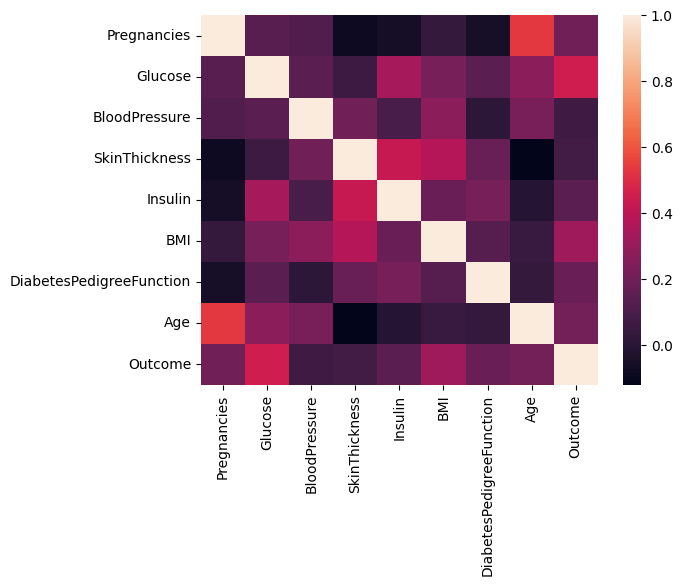

In [13]:
# Generate a heatmap of correlations between variables
# Lighter colors show high corlations; darker colors indicate low correlations
sns.heatmap(pima.corr())

In [14]:
# Look at the actual correlation coefficients
pima.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.139433,0.111983,-0.081693,-0.054951,0.034627,-0.052403,0.532680,0.207775
Glucose,0.139433,1.000000,0.145678,0.056046,0.340357,0.217588,0.145800,0.274985,0.450583
BloodPressure,0.111983,0.145678,1.000000,0.202412,0.095891,0.273212,0.013424,0.225346,0.065156
SkinThickness,-0.081693,0.056046,0.202412,1.000000,0.429565,0.379173,0.178160,-0.120020,0.077243
Insulin,-0.054951,0.340357,0.095891,0.429565,1.000000,0.185387,0.219091,-0.010462,0.146800
BMI,0.034627,0.217588,0.273212,0.379173,0.185387,1.000000,0.129418,0.048641,0.318086
DiabetesPedigreeFunction,-0.052403,0.145800,0.013424,0.178160,0.219091,0.129418,1.000000,0.034688,0.182794
Age,0.532680,0.274985,0.225346,-0.120020,-0.010462,0.048641,0.034688,1.000000,0.211984
Outcome,0.207775,0.450583,0.065156,0.077243,0.146800,0.318086,0.182794,0.211984,1.000000


## Correlation with heat map

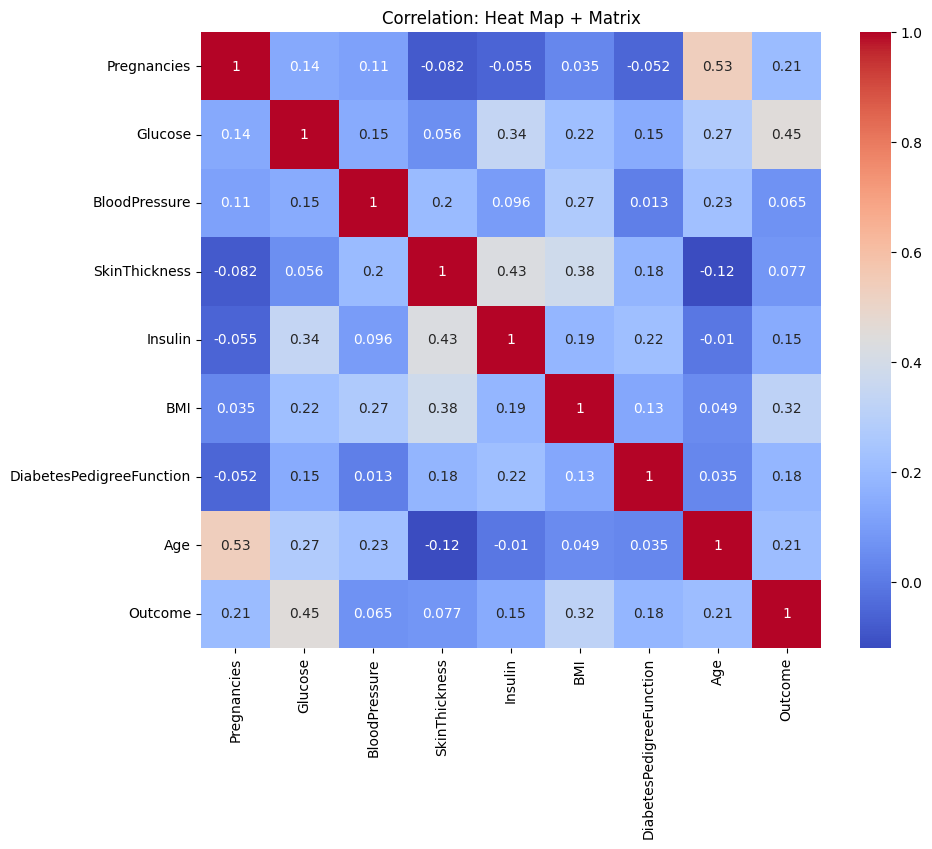

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(pima.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation: Heat Map + Matrix')
plt.show()

<Axes: xlabel='Outcome', ylabel='count'>

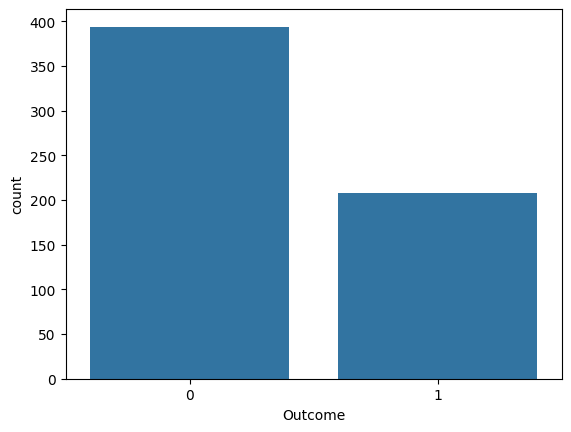

In [16]:
# Visually compare ratios of people with no diabetes (0) and with diabetes (1)
sns.countplot(x='Outcome', data=pima)

<Axes: xlabel='Outcome', ylabel='count'>

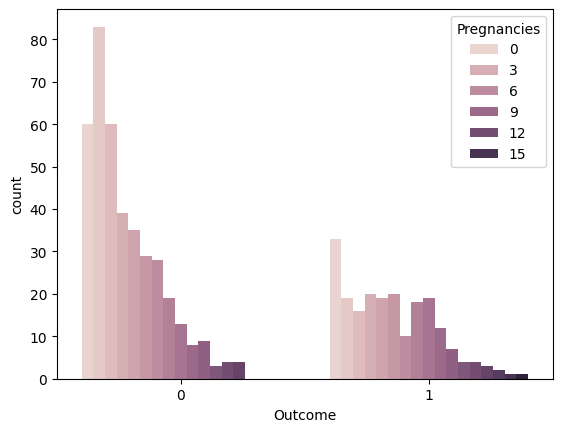

In [17]:
# Visually compare ratios of people with no diabetes along with count of pregnancies
sns.countplot(x='Outcome', data=pima, hue='Pregnancies')

(array([235., 123.,  78.,  66.,  33.,  25.,  26.,  13.,   2.,   1.]),
 array([21., 27., 33., 39., 45., 51., 57., 63., 69., 75., 81.]),
 <BarContainer object of 10 artists>)

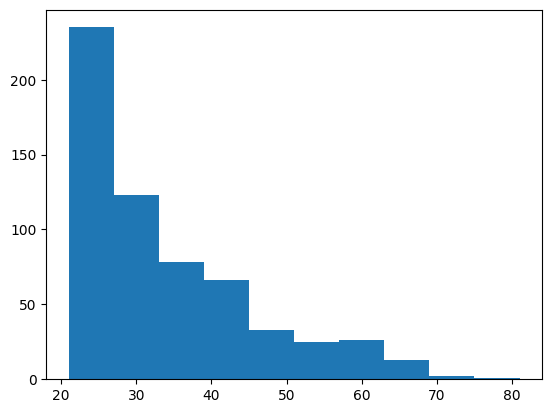

In [18]:
# Histogram of age distribution
plt.hist(pima['Age'])

<Axes: xlabel='Outcome', ylabel='Age'>

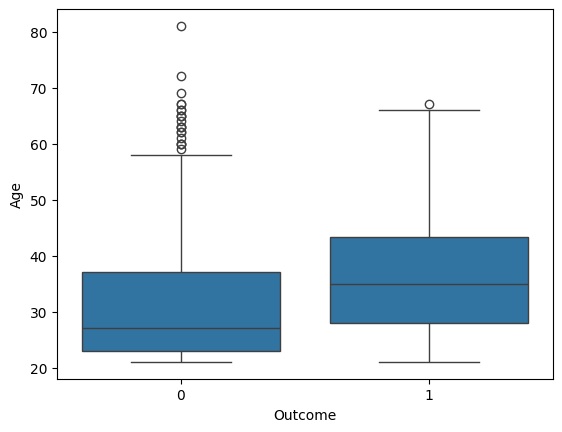

In [20]:
# Create a box plot
sns.boxplot(x=pima['Outcome'], y=pima['Age'])

### Box plot to explore relevant features of the data
As you can see, (1) the people with no diabestes (with an Outcome value of 0) tend to be younger  while the those who have diabestes tend to be older. (2) There are many ouliers in the case of people with no diabetes, i.e., many older people don't have diabetes. (3) Median age of people with diabetes is higher.

<h1><p style="color:green"> Logistic Regression Analysis Code Starts Here

## (a) Create separate data frames for explanatory and target variables

In [21]:
# Create a list of explanatory variables
# Notice that one of the variables "SkinThickness" is dropped in this example
# Subject area or domain knowledge is necessary to decide which variables are most relevant
# for analysis. Also, a low correlation between this variable and the outcome variable is another factor

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

# Create a data frame x for expalanatory variables and data frame y for target variable
X = pima[features] # Features
y = pima.Outcome

## (b) Split dataset into training and testing subsets

In [22]:
from sklearn.model_selection import train_test_split

'''
The random_state argument:  If we don't specify the random_state,
every time we run the code, new random values will be generated and the
train and test datasets would have different values each time.
However, if a fixed value is assigned like random_state = 99
then no matter how many times you execute your code the result would be the same
i.e, same values generated for train and test datasets. '''

# Split the dataset for taining and testing using 75% and 25% split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=99)

In [23]:
# Look at the shape of training data subsets
x_train.shape, y_train.shape

((451, 7), (451,))

In [24]:
# Look at the shape of the test data subset
x_test.shape, y_test.shape

((151, 7), (151,))

In [25]:
# Look at the head of the training data subset
x_train.head()

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age
555,7,124,70,215,25.5,0.161,37
44,7,159,64,0,27.4,0.294,40
365,5,99,54,83,34.0,0.499,30
136,0,100,70,50,30.8,0.597,21
594,6,123,72,230,33.6,0.733,34


## (c) Fit a model to the data

In [26]:
# Here the fitted model is named as logmodel
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(max_iter=200)
logmodel.fit(x_train,y_train)

LogisticRegression(max_iter=200)

## (d) Predict

In [27]:
# Use x_test hold-out subset to predict.
# y_test is for comparing predicted and actual values with y_predicted

y_predict = logmodel.predict(x_test)

In [28]:
# fit the model (using the default parameters)
logreg = LogisticRegression(max_iter=1000).fit(x_train,y_train)

In [29]:
# predict using the fitted model
y_pred=logreg.predict(x_test)

# Evalute the Model

## (e) Generate Classification Report

In [30]:
# Note: 0 = no diabetes, 1 = diabetes
# The two arguments to classification_report are y_test and y_predict

from sklearn.metrics import classification_report
classification_report(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80        95
           1       0.68      0.54      0.60        56

    accuracy                           0.74       151
   macro avg       0.72      0.69      0.70       151
weighted avg       0.73      0.74      0.73       151



## (f) Generate Confusion Matrix

#### TN  ... FP
#### FN  ... TP

In [31]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_predict))

[[81 14]
 [26 30]]


#### Accuracy = (TP + TN) / (TN+FP+FN+TP) = 153/192 = 0.80
#### TN + FP = 132 = Support
#### FN + TP = 60 = Support

<h1><p style="color:blue"> Logistic Regression Analysis Code Ends Here </p></h3> </p>

## Accuracy vs. F1 Score: Which one to use in evaluating the model?
### Accuracy:
Easy to interpret. If we say that a model is 90% accurate, we know that it correctly classified 90% of observations. Use Accuracy if the **data is balanced** and there is **no major downside to predicting false negatives.**
### F1 Score:
Takes into account how the data is distributed. For example, **if the data is highly imbalanced then F1 score will provide a better assessment of model performance.** Also, use **F1** score when there is **a serious downside to predicting false negatives.** For example, if we use a logistic regression model to predict whether or not someone has cancer, false negatives are really bad (e.g. predicting that someone does not have cancer when they actually do). F1 score penalizes models that have too many false negatives more than accuracy will.

<h1><p style="color:red"> Homework Starts Here:

# Homework Instructions

<h3><p style="color:red"> (1) Below this cell, add a code cell to read-in the diabetes dataset and create a data frame from it. <u> Name this data frame as your own last name </u> </p></h3>

In [33]:
import pandas as pd

# load dataset
huynh = pd.read_excel("/content/diabetes.xlsx")

# check first 5 rows
huynh.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<h3><p style="color:red"> (2) Add a code cell below this cell to show top three and bottom three rows from the dataset that you created in Step 1 </p></h3>

In [34]:
# Show top 3 rows
print("Top 3 rows:")
display(huynh.head(3))

# Show bottom 3 rows
print("Bottom 3 rows:")
display(huynh.tail(3))

Top 3 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


Bottom 3 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
599,1,109,38,18,120,23.1,0.407,26,0
600,1,108,88,19,0,27.1,0.400,24,0
601,6,96,0,0,0,23.7,0.190,28,0


<h3><p style="color:red"> (3) Add a code cell below this cell to display a correlation matrix for all the variables in the data frame </p></h3>

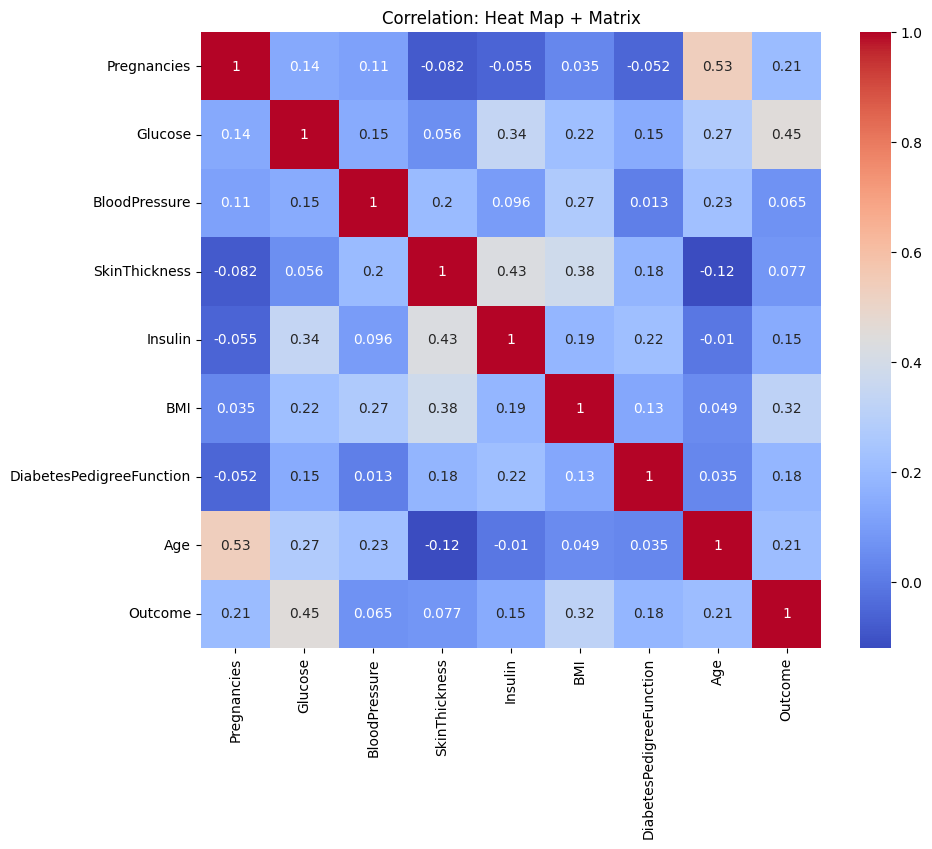

In [35]:
#correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(pima.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation: Heat Map + Matrix')
plt.show()

<h3><p style="color:red"> (4) Add as many <u> code cells </u> as needed below to do the Logistic Regression work done in the first part of this notebook starting with Step(a) through Step(f). For this homework, please select and use any <u> FIVE variables </u> from the data frame, instead of the SEVEN used in the first part of this notebook.
    
 </p></h3>

In [41]:
# 5 Variables
X = huynh[['Glucose','BMI','Age','BloodPressure','Insulin']]
# Target Variable
y = huynh.Outcome

from sklearn.model_selection import train_test_split

# Split the dataset for taining and testing using 75% and 25% split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=99)

# Look at the shape of training data subsets
x_train.shape, y_train.shape

# Look at the shape of the test data subset
x_test.shape, y_test.shape

# Look at the head of the training data subset
x_train.head()

# Here the fitted model is named as logmodel
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression(max_iter=200)
logmodel.fit(x_train,y_train)

# Use x_test hold-out subset to predict.
# y_test is for comparing predicted and actual values with y_predicted

y_predict = logmodel.predict(x_test)

# fit the model (using the default parameters)
logreg = LogisticRegression(max_iter=1000).fit(x_train,y_train)

# predict using the fitted model
y_pred=logreg.predict(x_test)

In [42]:
# Note: 0 = no diabetes, 1 = diabetes
# The two arguments to classification_report are y_test and y_predict

from sklearn.metrics import classification_report
classification_report(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81        95
           1       0.70      0.57      0.63        56

    accuracy                           0.75       151
   macro avg       0.73      0.71      0.72       151
weighted avg       0.74      0.75      0.74       151



In [43]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_predict))

[[81 14]
 [24 32]]


In [45]:
# TN ... FP
# FN ... TP

Accuracy = (TP + TN) / (TN+FP+FN+TP) = (32+81) / (81+14+24+32) = 113 / 151 = 0.74834437086

<h3><p style="color:red"> (5) Add a Markdown (or Text) cell below this cell in which you should please write a brief formatted report describing the <u> quality of the model by interpreting its accuracy rate </u>  </p></h3>

The logistic regression model was developed to predict diabetes outcomes based on the 5 variables selected: Glucose, BMI, Age, BloodPressure, and Insulin. The diabetes dataset was split into training and testing sets. (75% training and 25% testing)

The logistic regression model received an accuracy score of 0.748, showing that the model correctly classified those with diabetes with 74.8% accuracy based on the variables chosen.